In [1]:
%pip install mlxtend
%pip install - -upgrade pip
%pip install networkx
%pip install openpyxl


[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

Usage:   
  /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install [options] <requirement specifier> [package-index-options] ...
  /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install [options] -r <requirements file> [package-index-options] ...
  /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install [options] [-e] <vcs project url> ...
  /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install [options] [-e] <local project path> ...
  /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install [options] <archive url/path> ...

no such option: -u
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use 

In [2]:
import pandas as pd
from pandas.io.formats.style import Styler
import seaborn as sns
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import networkx as nx
%matplotlib inline
sns.set()

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from mlxtend.frequent_patterns import fpgrowth, association_rules, apriori

pd.set_option("display.max_columns", 300)

/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_14348/4229447271.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [3]:
vlna_1 = pd.read_excel("1. vlna všetko 28-11-2024.xlsx")  
vlna_1

vlna_4 = pd.read_excel("4. vlna všetko 28-11-2024.xlsx")  
vlna_4

,Poradie,Meno,Pohlavie,Vek,Dátum príjmu,Kód príjmu,Dátum prepustenia,Kód prepustenia,HLN Dg.,Diagnózy,DRG výkony,Liečba,SVLZ správy,Mikrobiológia,Epikríza,Terajšie ochorenie,Dôvod hospitalizácie,Objektívny nález,Osobná anamnéza,Lieková anamnéza,Návyková anamnéza,Epidemiologická anamnéza,A04.7,Unnamed: 23,Závažnosť priebehu ochorenia,Fajčenie,Alkohol,S-Bil-T first,S-Bil-T last,S-Bil-T min,S-Bil-T max,S-AST first,S-AST last,S-AST min,S-AST max,S-ALT first,S-ALT last,S-ALT min,S-ALT max,S-GMT first,S-GMT last,S-GMT min,S-GMT max,S-ALP first,S-ALP last,S-ALP min,S-ALP max,S-Chol first,S-Chol last,S-Chol min,S-Chol max,S-CB first,S-CB last,S-CB min,S-CB max,S-Na first,S-Na last,S-Na min,S-Na max,S-K first,S-K last,S-K min,S-K max,S-CL first,S-CL last,S-CL min,S-CL max,S-IgG first,S-IgG last,S-IgG min,S-IgG max,S-IgA first,S-IgA last,S-IgA min,S-IgA max,S-Ig M first,S-Ig M last,S-Ig M min,S-Ig M max,S-CRP first,S-CRP last,S-CRP min,S-CRP max,S-Alb first,S-Alb last,S-Alb min,S-Alb max,S-Gluk first,S-Gluk last,S-Gluk min,S-Gluk max,S-Urea first,S-Urea last,S-Urea min,S-Urea max,S-Kreat first,S-Kreat last,S-Kreat min,S-Kreat max,S-KM first,S-KM last,S-KM min,S-KM max,S-AMS first,S-AMS last,S-AMS min,S-AMS max,S-CK first,S-CK last,S-CK min,S-CK max,S-CK-MB first,S-CK-MB last,S-CK-MB min,S-CK-MB max,S-LD first,S-LD last,S-LD min,S-LD max,P-Laktát first,P-Laktát last,P-Laktát min,P-Laktát max,S-FER first,S-FER last,S-FER min,S-FER max,S-IL6 first,S-IL6 last,S-IL6 min,S-IL6 max,HGB first,HGB last,HGB min,HGB max,WBC first,WBC last,WBC min,WBC max,PLT first,PLT last,PLT min,PLT max,Neu abs first,Neu abs last,Neu abs min,Neu abs max,Eo abs first,Eo abs last,Eo abs min,Eo abs max,Ly abs first,Ly abs last,Ly abs min,Ly abs max,PT (INR) first,PT (INR) last,PT (INR) min,PT (INR) max,APTT-R first,APTT-R last,APTT-R min,APTT-R max,Fib first,Fib last,Fib min,Fib max,CD3+ first,CD3+ last,CD3+ min,CD3+ max,CD4+ first,CD4+ last,CD4+ min,CD4+ max,CD8+ first,CD8+ last,CD8+ min,CD8+ max,CD4+/CD8+ first,CD4+/CD8+ last,CD4+/CD8+ min,CD4+/CD8+ max,PDW first,PDW last,PDW min,PDW max,CD19+ first,CD19+ last,CD19+ min,CD19+ max,NK first,NK last,NK min,NK max,NE/LY(NLR) first,NE/LY(NLR) last,NE/LY(NLR) min,NE/LY(NLR) max,D-dimér HS first,D-dimér HS last,D-dimér HS min,D-dimér HS max,SatO2 %,Hypertenzia,Diabetes mellitus,Kardiovaskulárne ochorenia,Chronické respiračné ochorenia,Renálne ochorenia,Pečeňové ochorenia,Onkologické ochorenia,Imunosupresia,Vakcinácia,Typ vakcíny,Počet dávok,MD652 | FABIFLU TABLETS,MD656 IV-BECT 6MG (ivermectin),5042D | VEKLURY,9547D | PAXLOVID,LAGEVRIO,00584 | PYRIDOXIN LÉČIVA INJ,24836 | ACIDUM ASCORBICUM BBP,"24814 | CALCIFEROL BBP 7,5 MG/ML",00498 | MAGNESIUM SULFURICUM BBP 100 MG/ML INJEKČNÝ ROZTOK,00449 | EREVIT 300 MG/ML,89145 | VITAMIN C-INJEKTOPAS,92973 ALPHA D3,02963 | PREDNISON 20 LÉČIVA,00269 | PREDNISON 5 LÉČIVA,84090 | DEXAMED 6,1275C | DEXAMETAZÓN KRKA,MD661 BIODEXONE-DEXAMETHASONE,2410B HYDROCORTISONE,3242C | OLUMIANT 4 MG,Anakinra,RoActemra,34045 | POLYOXIDONIUM 6 MG,87299 | IMUNOR,56930 IMMODIN,"Isoprinosine,",3879d INOMED,35715 Azithromycin,45954 Ceftriaxon,0471B MOLOXIN,9819A MOXIFLOXACIN,58730 CIPROFLOXACIN KABI 200,58746 CIPROFLOXACINKABI 400,05044 OZZION,4147C OMEMYL,89662 NOLPAZA,39397 PANTOPRAZOL,62916 SMECTA,30639 REASEC,84370 LAGOSA,93105 DEGAN,94918 AMBROBENE,24859 PENTOXYPHILLINUM,8893 ACC INJEKT,24949 CODEIN,26846 OXANTIL,FRAXIPARIN,CLEXANE,FRAGMIN,ASPIRIN,ANOPYRIN,Prekonal COVID-19,S-PBNP first,S-PBNP last,S-PBNP min,S-PBNP max,S-VITD first,S-VITD last,S-VITD min,S-VITD max
0,1,TOHAMJTTYUMQPEAPLOLF,Žena,67,01.01.2022,1,10.01.2022,7,J12.8 | Iný vírusový zápal pľúc | B,U07.3 | Potvrdená infekcia COVID-19 PCR testom...,8p100.6 | Ventilačná podpora vysokým prietokom...,01125 | MORPHIN BIOTIKA 1% | 3; _x000D_\n02479...,"Popis: 03.01.2022 | RTG ko., porovnávané s vyš...",02.01.2022 07:31:00 | zaplava amorf. soli ; _x...,"Epikríza: 67- ročná obézna pacientka, neočkova...","TO: Chorá sa cíti od 27.12.2021, má teplo

In [4]:
# odstránenie identifikátorov
drop_cols = ["Poradie", "Meno"]
vlna_1 = vlna_1.drop(columns=drop_cols, errors="ignore")
drop_cols = ["Poradie", "Meno"]
vlna_4 = vlna_4.drop(columns=drop_cols, errors="ignore")


In [5]:
vlna_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1124 entries, 0 to 1123
Columns: 272 entries, Pohlavie to S-VITD max
dtypes: bool(63), float64(186), int64(5), object(18)
memory usage: 1.9+ MB


In [6]:
vlna_1

,Pohlavie,Vek,Dátum príjmu,Kód príjmu,Dátum prepustenia,Kód prepustenia,HLN Dg.,Diagnózy,DRG výkony,Liečba,SVLZ správy,Mikrobiológia,Epikríza,Terajšie ochorenie,Dôvod hospitalizácie,Objektívny nález,Osobná anamnéza,Lieková anamnéza,Návyková anamnéza,Epidemiologická anamnéza,A04.7,Unnamed: 23,Závažnosť priebehu ochorenia,Fajčenie,Alkohol,S-Bil-T first,S-Bil-T last,S-Bil-T min,S-Bil-T max,S-AST first,S-AST last,S-AST min,S-AST max,S-ALT first,S-ALT last,S-ALT min,S-ALT max,S-GMT first,S-GMT last,S-GMT min,S-GMT max,S-ALP first,S-ALP last,S-ALP min,S-ALP max,S-Chol first,S-Chol last,S-Chol min,S-Chol max,S-CB first,S-CB last,S-CB min,S-CB max,S-Na first,S-Na last,S-Na min,S-Na max,S-K first,S-K last,S-K min,S-K max,S-CL first,S-CL last,S-CL min,S-CL max,S-IgG first,S-IgG last,S-IgG min,S-IgG max,S-IgA first,S-IgA last,S-IgA min,S-IgA max,S-Ig M first,S-Ig M last,S-Ig M min,S-Ig M max,S-CRP first,S-CRP last,S-CRP min,S-CRP max,S-Alb first,S-Alb last,S-Alb min,S-Alb max,S-Gluk first,S-Gluk last,S-Gluk min,S-Gluk max,S-Urea first,S-Urea last,S-Urea min,S-Urea max,S-Kreat first,S-Kreat last,S-Kreat min,S-Kreat max,S-KM first,S-KM last,S-KM min,S-KM max,S-AMS first,S-AMS last,S-AMS min,S-AMS max,S-CK first,S-CK last,S-CK min,S-CK max,S-CK-MB first,S-CK-MB last,S-CK-MB min,S-CK-MB max,S-LD first,S-LD last,S-LD min,S-LD max,P-Laktát first,P-Laktát last,P-Laktát min,P-Laktát max,S-FER first,S-FER last,S-FER min,S-FER max,S-IL6 first,S-IL6 last,S-IL6 min,S-IL6 max,HGB first,HGB last,HGB min,HGB max,WBC first,WBC last,WBC min,WBC max,PLT first,PLT last,PLT min,PLT max,Neu abs first,Neu abs last,Neu abs min,Neu abs max,Eo abs first,Eo abs last,Eo abs min,Eo abs max,Ly abs first,Ly abs last,Ly abs min,Ly abs max,PT (INR) first,PT (INR) last,PT (INR) min,PT (INR) max,APTT-R first,APTT-R last,APTT-R min,APTT-R max,Fib first,Fib last,Fib min,Fib max,CD3+ first,CD3+ last,CD3+ min,CD3+ max,CD4+ first,CD4+ last,CD4+ min,CD4+ max,CD8+ first,CD8+ last,CD8+ min,CD8+ max,CD4+/CD8+ first,CD4+/CD8+ last,CD4+/CD8+ min,CD4+/CD8+ max,PDW first,PDW last,PDW min,PDW max,CD19+ first,CD19+ last,CD19+ min,CD19+ max,NK first,NK last,NK min,NK max,NE/LY(NLR) first,NE/LY(NLR) last,NE/LY(NLR) min,NE/LY(NLR) max,D-dimér HS first,D-dimér HS last,D-dimér HS min,D-dimér HS max,SatO2 %,Hypertenzia,Diabetes mellitus,Kardiovaskulárne ochorenia,Chronické respiračné ochorenia,Renálne ochorenia,Pečeňové ochorenia,Onkologické ochorenia,Imunosupresia,Vakcinácia,Typ vakcíny,Počet dávok,MD652 | FABIFLU TABLETS,MD656 IV-BECT 6MG (ivermectin),5042D | VEKLURY,9547D | PAXLOVID,LAGEVRIO,00584 | PYRIDOXIN LÉČIVA INJ,24836 | ACIDUM ASCORBICUM BBP,"24814 | CALCIFEROL BBP 7,5 MG/ML",00498 | MAGNESIUM SULFURICUM BBP 100 MG/ML INJEKČNÝ ROZTOK,00449 | EREVIT 300 MG/ML,89145 | VITAMIN C-INJEKTOPAS,92973 ALPHA D3,02963 | PREDNISON 20 LÉČIVA,00269 | PREDNISON 5 LÉČIVA,84090 | DEXAMED 6,1275C | DEXAMETAZÓN KRKA,MD661 BIODEXONE-DEXAMETHASONE,2410B HYDROCORTISONE,3242C | OLUMIANT 4 MG,Anakinra,RoActemra,34045 | POLYOXIDONIUM 6 MG,87299 | IMUNOR,56930 IMMODIN,"Isoprinosine,",3879d INOMED,35715 Azithromycin,45954 Ceftriaxon,0471B MOLOXIN,9819A MOXIFLOXACIN,58730 CIPROFLOXACIN KABI 200,58746 CIPROFLOXACINKABI 400,05044 OZZION,4147C OMEMYL,89662 NOLPAZA,39397 PANTOPRAZOL,62916 SMECTA,30639 REASEC,84370 LAGOSA,93105 DEGAN,94918 AMBROBENE,24859 PENTOXYPHILLINUM,8893 ACC INJEKT,24949 CODEIN,26846 OXANTIL,FRAXIPARIN,CLEXANE,FRAGMIN,ASPIRIN,ANOPYRIN,Prekonal COVID-19,S-PBNP first,S-PBNP last,S-PBNP min,S-PBNP max,S-VITD first,S-VITD last,S-VITD min,S-VITD max
0,Žena,75,23.11.2020,1,30.11.2020,1,J12.8 | Iný vírusový zápal pľúc | B,J12.8 | Iný vírusový zápal pľúc | B; _x000D_\n...,33000.3 | CT v oblasti hrudníka | 24.11.2020 |...,05044 | OZZION 20 MG GASTROREZISTENTNÉ TABLETY...,Popis: 24.11.2020 | Natívne vyš. v režime HRCT...,NaN,75-ročná pacientka prijatá pre potvrdenú COVID...,"TO: Od 14.11.2020 COVID19+, stále teplotuje, m...",Dôvod hospitalizácie: Pacientka prijatá pre ví...,"Status praesens: Pri vedo

In [7]:
print(vlna_1.Pohlavie.value_counts())
print(vlna_1.Vek.value_counts())

Pohlavie
Muž     563
Žena    561
Name: count, dtype: int64
Vek
64    37
63    34
70    34
67    33
66    32
      ..
92     1
22     1
95     1
21     1
19     1
Name: count, Length: 77, dtype: int64


In [8]:
print(vlna_1["Kód príjmu"].value_counts())

Kód príjmu
1    1115
3       9
Name: count, dtype: int64


In [9]:
# funkcia na nahradenie nezmyselných hodnôt 'Other' najčastejšou hodnotou pre daný atribút
def nahradenie(vlna_1, column_name):
    most_common_value = vlna_1[column_name].mode()[0]
    vlna_1.loc[vlna_1[column_name] == 'Other', column_name] = most_common_value
    return most_common_value

print("Najčastejšia hodnota pre 'vek':")
najcastejsi_vek = nahradenie(vlna_1, 'Vek')
print(najcastejsi_vek)

Najčastejšia hodnota pre 'vek':
64


/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_14348/1717447097.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=vlna_1, x="Pohlavie", ax=ax, palette='flare')


Text(0.5, 1.0, 'Pacienti podľa pohlavia')

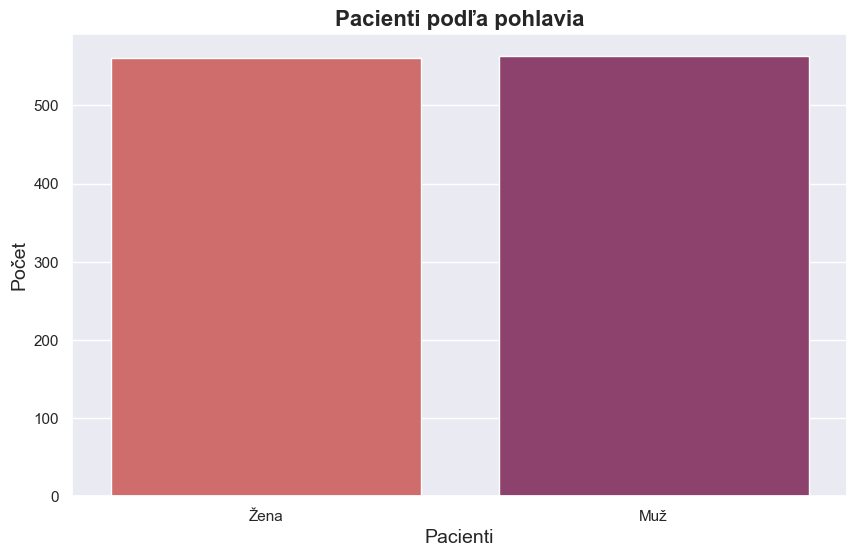

In [10]:
# Vytvorenie figúry a osi pre grafové objekty
fig, ax = plt.subplots(figsize=(10, 6))

# Pacienti podľa pohlavia
sns.countplot(data=vlna_1, x="Pohlavie", ax=ax, palette='flare')
ax.set_xlabel("Pacienti", fontsize=14)
ax.set_ylabel("Počet", fontsize=14)
ax.set_title("Pacienti podľa pohlavia", fontsize=16, fontweight='bold')

/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_14348/407705198.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=vlna_1, y="vekova_skupina", palette='flare')


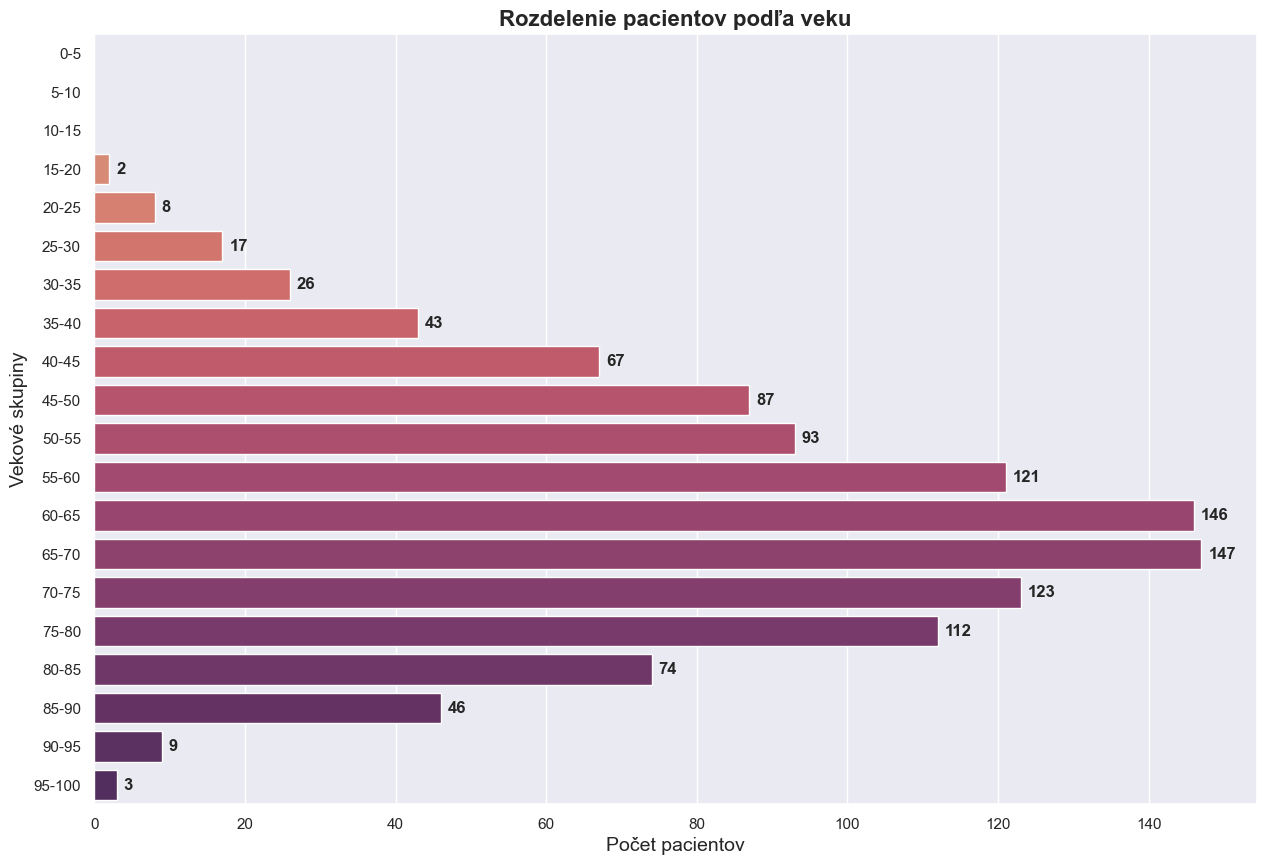

In [11]:
# HISTOGRAM - rozdelenie pacientov do vekových skupín
# Definovanie hraníc od 0 do 100 s krokom 5
bins = list(range(0, 101, 5)) 

# Automatické vygenerovanie labelov vo formáte '0-5', '5-10', atď.
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
vlna_1['vekova_skupina'] = pd.cut(vlna_1['Vek'], bins=bins, labels=labels, include_lowest=True)

plt.figure(figsize=(15, 10))
ax = sns.countplot(data=vlna_1, y="vekova_skupina", palette='flare')

# DOPLNENÝ KÓD PRE ZOBRAZENIE POČTU
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}', 
                (width, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), 
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.xlabel("Počet pacientov", fontsize=14)
plt.ylabel("Vekové skupiny", fontsize=14)
plt.title("Rozdelenie pacientov podľa veku", fontsize=16, fontweight='bold')
plt.show()


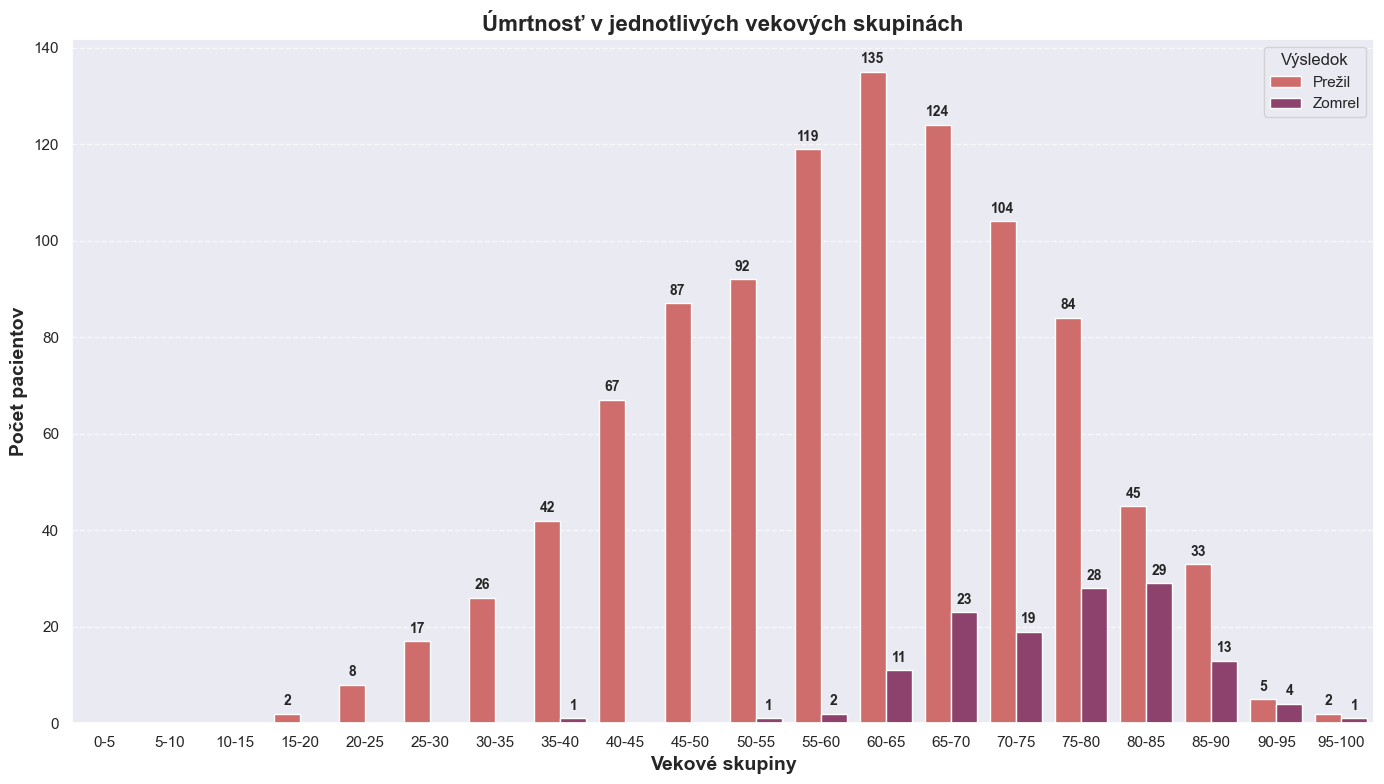

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. POISTKA: Skontrolujeme, či 'Zomrel' existuje. Ak nie, vytvoríme ho.
if 'Zomrel' not in vlna_1.columns:
    if 'Kód prepustenia' in vlna_1.columns:
        vlna_1['Zomrel'] = (vlna_1['Závažnosť priebehu ochorenia'] == 3)
    else:
        # Ak nemáš ani 'Zomrel' ani 'Kód prepustenia', vypíšeme stĺpce, aby sme videli chybu
        print("Chyba: Stĺpec 'Zomrel' sa nenašiel. Dostupné stĺpce sú:", vlna_1.columns.tolist())

# 2. Príprava stĺpca 'Stav' pre krajšiu legendu
vlna_1['Stav'] = vlna_1['Zomrel'].map({True: 'Zomrel', False: 'Prežil', 1: 'Zomrel', 0: 'Prežil'})

# 3. VYKRESLENIE (Skupinový graf - Grouped Bar Chart)
plt.figure(figsize=(14, 8))

# Použijeme kontrastné medicínske farby (Červená = Nebezpečenstvo, Zelená = Bezpečie)
ax = sns.countplot(data=vlna_1, x="vekova_skupina", hue="Stav", 
                   palette='flare')

# Pridanie popiskov
plt.xlabel("Vekové skupiny", fontsize=14, fontweight='bold')
plt.ylabel("Počet pacientov", fontsize=14, fontweight='bold')
plt.title("Úmrtnosť v jednotlivých vekových skupinách", fontsize=16, fontweight='bold')
plt.legend(title="Výsledok")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Pridanie číselných hodnôt nad stĺpce
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Nezobrazuj nuly
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

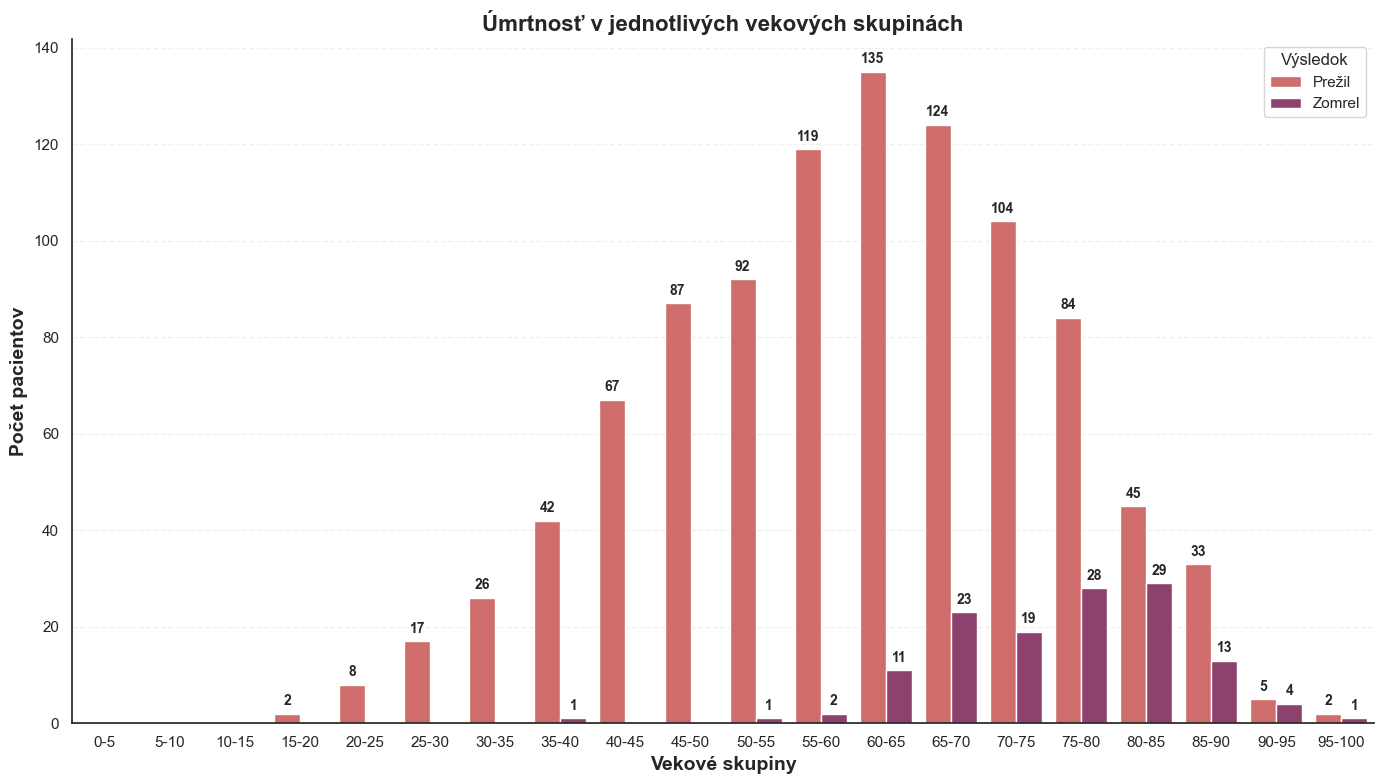

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Nastavenie bieleho pozadia
sns.set_style("white") 

# 1. POISTKA: Skontrolujeme, či 'Zomrel' existuje.
if 'Zomrel' not in vlna_1.columns:
    if 'Závažnosť priebehu ochorenia' in vlna_1.columns:
        vlna_1['Zomrel'] = (vlna_1['Závažnosť priebehu ochorenia'] == 3)
    else:
        print("Chyba: Stĺpec 'Zomrel' sa nenašiel. Dostupné stĺpce sú:", vlna_1.columns.tolist())

# 2. Príprava stĺpca 'Stav' a kontrola typov
# Uistíme sa, že 'Zomrel' je typu bool alebo int (0/1) pre mapovanie
vlna_1['Zomrel'] = vlna_1['Zomrel'].astype(int)
vlna_1['Stav'] = vlna_1['Zomrel'].map({1: 'Zomrel', 0: 'Prežil'})

# 3. VYKRESLENIE
plt.figure(figsize=(14, 8), facecolor='white') 

# KĽÚČOVÁ ZMENA: Pridaný hue_order=['Zomrel', 'Prežil']
# Tým povieme, že 'Zomrel' má byť vykreslený ako prvý a dostať prvú (tmavšiu/fialovú) farbu z palety
ax = sns.countplot(data=vlna_1, x="vekova_skupina", hue="Stav", 
                   palette='flare', hue_order=['Prežil', 'Zomrel'])

# Odstránenie horného a pravého okraja
sns.despine()

# Pridanie popiskov
plt.xlabel("Vekové skupiny", fontsize=14, fontweight='bold')
plt.ylabel("Počet pacientov", fontsize=14, fontweight='bold')
plt.title("Úmrtnosť v jednotlivých vekových skupinách", fontsize=16, fontweight='bold')
plt.legend(title="Výsledok")

# Jemná mriežka
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Pridanie číselných hodnôt nad stĺpce
for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

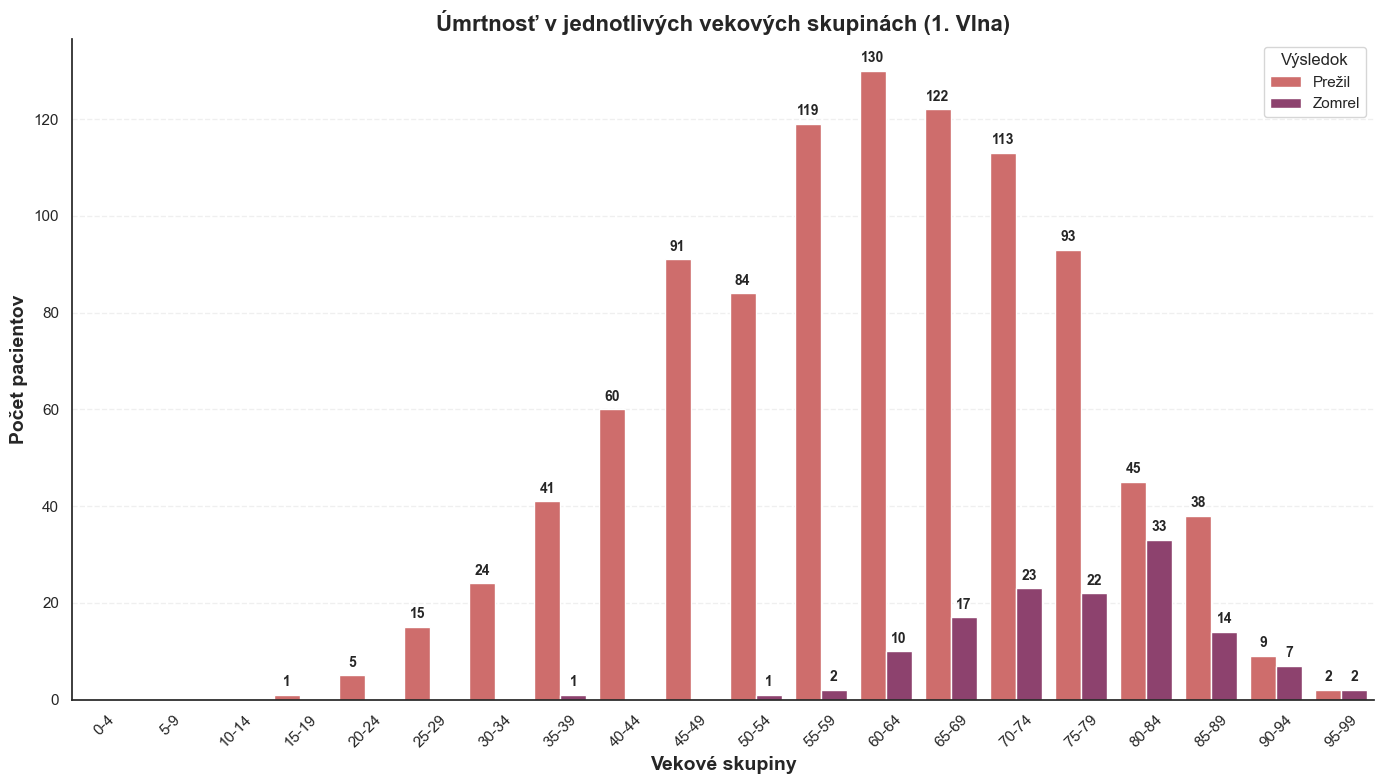

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Nastavenie bieleho pozadia
sns.set_style("white") 

# 1. POISTKA A PRÍPRAVA DÁT: Skontrolujeme stĺpce a vytvoríme 5-ročné kategórie
if 'Zomrel' not in vlna_1.columns:
    if 'Závažnosť priebehu ochorenia' in vlna_1.columns:
        vlna_1['Zomrel'] = (vlna_1['Závažnosť priebehu ochorenia'] == 3).astype(int)
    else:
        print("Chyba: Stĺpec 'Zomrel' sa nenašiel.")

# Vytvorenie 5-ročných intervalov (0-4, 5-9, ...)
bins = list(range(0, 105, 5))
labels = [f"{i}-{i+4}" for i in range(0, 100, 5)]
vlna_1['vek_5_rocne'] = pd.cut(vlna_1['Vek'], bins=bins, labels=labels, right=False)

# 2. Príprava stĺpca 'Stav' a kontrola typov
vlna_1['Zomrel'] = vlna_1['Zomrel'].astype(int)
vlna_1['Stav'] = vlna_1['Zomrel'].map({1: 'Zomrel', 0: 'Prežil'})

# 3. VYKRESLENIE
plt.figure(figsize=(14, 8), facecolor='white') 

# KĽÚČOVÁ ZMENA: hue_order nastavený tak, aby 'Zomrel' bol fialový (druhá farba v flare)
ax = sns.countplot(data=vlna_1, x="vek_5_rocne", hue="Stav", 
                   palette='flare', hue_order=['Prežil', 'Zomrel'])

# Odstránenie horného a pravého okraja
sns.despine()

# Pridanie popiskov
plt.xlabel("Vekové skupiny", fontsize=14, fontweight='bold')
plt.ylabel("Počet pacientov", fontsize=14, fontweight='bold')
plt.title("Úmrtnosť v jednotlivých vekových skupinách (1. Vlna)", fontsize=16, fontweight='bold')
plt.xticks(rotation=45) 
plt.legend(title="Výsledok")

# Jemná mriežka
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Pridanie číselných hodnôt nad stĺpce
for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [15]:
# Najmladší pacient
najmladsi = vlna_1["Vek"].min()

# Najstarší pacient
najstarsi = vlna_1["Vek"].max()

print(f"Najmladší pacient má {najmladsi} rokov.")
print(f"Najstarší pacient má {najstarsi} rokov.")

Najmladší pacient má 19 rokov.
Najstarší pacient má 99 rokov.


--- PRÍPRAVA DÁT PRE DALŠIE GRAFY ---

In [16]:
# Prevod dátumov na datetime formát
vlna_1['Dátum príjmu'] = pd.to_datetime(vlna_1['Dátum príjmu'], errors='coerce')
vlna_1['Dátum prepustenia'] = pd.to_datetime(vlna_1['Dátum prepustenia'], errors='coerce')

# Výpočet dĺžky hospitalizácie v dňoch
vlna_1['Dĺžka hospitalizácie'] = (vlna_1['Dátum prepustenia'] - vlna_1['Dátum príjmu']).dt.days

/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_14348/2176250334.py:2: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  vlna_1['Dátum príjmu'] = pd.to_datetime(vlna_1['Dátum príjmu'], errors='coerce')
/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_14348/2176250334.py:3: UserWarning: Parsing dates in %d.%m.%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  vlna_1['Dátum prepustenia'] = pd.to_datetime(vlna_1['Dátum prepustenia'], errors='coerce')


In [17]:
# Nastavenie štýlu grafov
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

VIZUALIZÁCIA
1. graf - závažnosť priebehu ochorenia (bar chart)

/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_14348/2863607042.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=zavaznost_counts.index, y=zavaznost_counts.values, palette='flare')


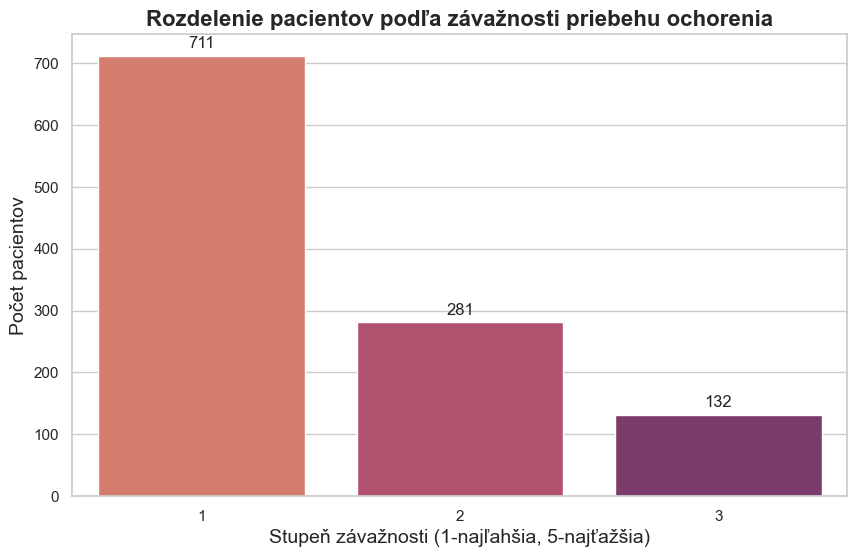

In [18]:
plt.figure(figsize=(10, 6))
zavaznost_counts = vlna_1['Závažnosť priebehu ochorenia'].value_counts().sort_index()
ax1 = sns.barplot(x=zavaznost_counts.index, y=zavaznost_counts.values, palette='flare')
plt.title('Rozdelenie pacientov podľa závažnosti priebehu ochorenia', fontsize=16, fontweight='bold')
plt.xlabel('Stupeň závažnosti (1-najľahšia, 5-najťažšia)', fontsize=14)
plt.ylabel('Počet pacientov', fontsize=14)

# Pridanie čísiel nad stĺpce
for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.show()

In [19]:
# Zistíme presné počty pre každú hodnotu závažnosti
print(vlna_1['Závažnosť priebehu ochorenia'].value_counts())

# Pozrieme sa, či tam nie sú nejaké chyby (napr. či nie sú tie čísla zapísané ako text)
print(vlna_1['Závažnosť priebehu ochorenia'].unique())

Závažnosť priebehu ochorenia
1    711
2    281
3    132
Name: count, dtype: int64
[1 3 2]


"Analýza prvej vlny ukázala vysokú koncentráciu pacientov so stupňom závažnosti 3, zatiaľ čo stupne 4 a 5 neboli v sledovanej vzorke zastúpené. Tento fakt naznačuje odlišný manažment pacientov alebo nižšiu virulenciu v porovnaní s nasledujúcimi vlnami, kde budeme sledovať posun k vyššej závažnosti"

2. graf - dĺžka hospitalizácie (boxplot)

/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_14348/2684335226.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=vlna_1['Dĺžka hospitalizácie'], fliersize=5, palette='flare')


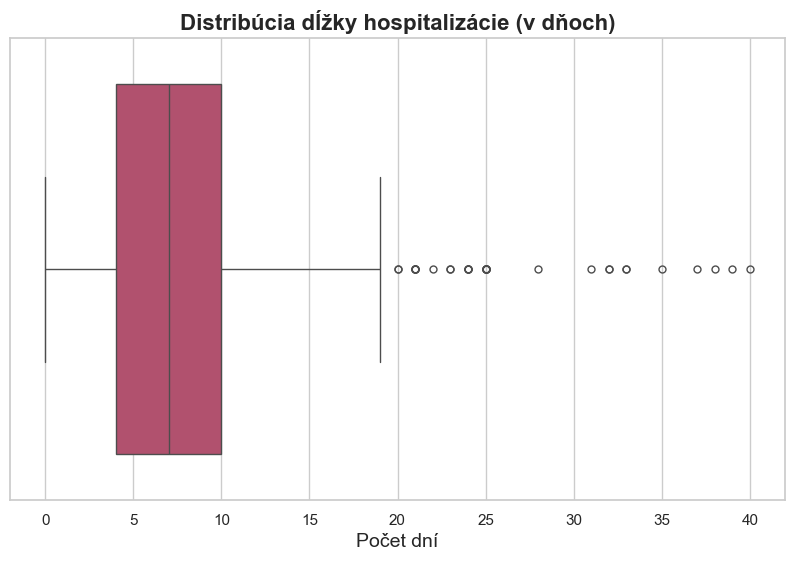

In [20]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=vlna_1['Dĺžka hospitalizácie'], fliersize=5, palette='flare')
plt.title('Distribúcia dĺžky hospitalizácie (v dňoch)', fontsize=16, fontweight='bold')
plt.xlabel('Počet dní', fontsize=14)
plt.show()

/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_14348/1456458489.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=vlna_1,


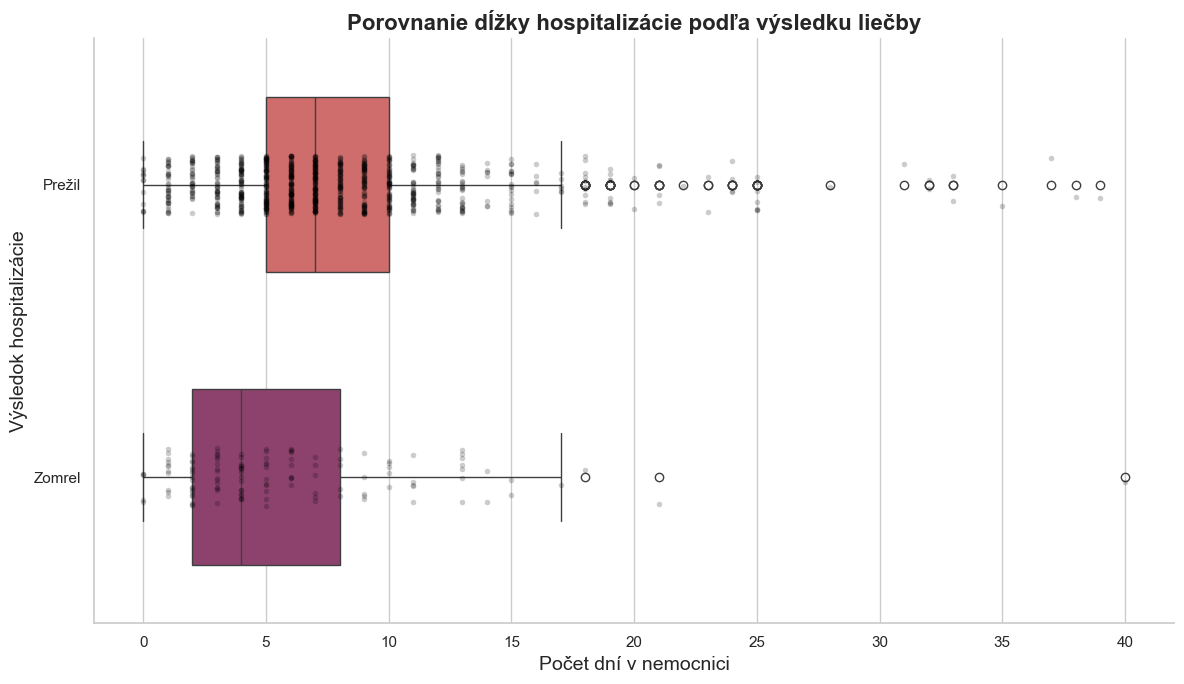

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. POISTKA: Príprava stĺpca 'Stav' pre legendu a os, ak náhodou neexistuje
if 'Stav' not in vlna_1.columns:
    vlna_1['Stav'] = vlna_1['Zomrel'].map({True: 'Zomrel', False: 'Prežil', 1: 'Zomrel', 0: 'Prežil'})

plt.figure(figsize=(12, 7))

# 2. VYKRESLENIE: Boxplot rozdelený podľa stavu
# Používame orientáciu 'h' (horizontálnu), aby boli popisy lepšie čitateľné
ax = sns.boxplot(data=vlna_1, 
                 x='Dĺžka hospitalizácie', 
                 y='Stav', 
                 palette="flare",
                 width=0.6)

# 3. VOLITEĽNÉ: Pridanie jednotlivých bodov (pacientov) pre lepšiu vizualizáciu hustoty
sns.stripplot(data=vlna_1, 
              x='Dĺžka hospitalizácie', 
              y='Stav', 
              color='black', 
              alpha=0.2, 
              size=4)

# 4. ÚPRAVA DIZAJNU
plt.title('Porovnanie dĺžky hospitalizácie podľa výsledku liečby', fontsize=16, fontweight='bold')
plt.xlabel('Počet dní v nemocnici', fontsize=14)
plt.ylabel('Výsledok hospitalizácie', fontsize=14)

# Odstránenie rámov pre moderný "vedecký" vzhľad
sns.despine()

plt.tight_layout()
plt.show()

„Tento porovnávací boxplot vizualizuje rozdiel v dĺžke hospitalizácie medzi skupinami pacientov. Vidíme, že skupina pacientov, ktorí ochoreniu podľahli, vykazuje [nižší/vyšší] medián času stráveného v nemocnici. Prítomnosť výrazných odľahlých hodnôt v oboch skupinách potvrdzuje extrémne individuálny priebeh ochorenia COVID-19, kde dĺžka hospitalizácie niekedy presiahla aj 30 a viac dní, čo pravdepodobne súvisí s rozvojom komplikácií.“

In [22]:
# Výpočet štatistík pre obe skupiny
stats = vlna_1.groupby('Stav')['Dĺžka hospitalizácie'].agg(['mean', 'median', 'std', 'min', 'max', 'count']).round(2)

# Premenovanie stĺpcov pre lepšiu prehľadnosť
stats.columns = ['Priemer (dni)', 'Medián (dni)', 'Smerodajná odchýlka', 'Min', 'Max', 'Počet pacientov']

print("Štatistické porovnanie dĺžky hospitalizácie:")
display(stats)

# Pomocný výpočet pre tvoj text v DP
median_prezil = stats.loc['Prežil', 'Medián (dni)']
median_zomrel = stats.loc['Zomrel', 'Medián (dni)']
rozdiel = abs(median_prezil - median_zomrel)

print(f"\nTIP DO TEXTU:")
print(f"Medián dĺžky hospitalizácie u pacientov, ktorí prežili, bol {median_prezil} dní,")
print(f"zatiaľ čo u pacientov, ktorí zomreli, to bolo {median_zomrel} dní.")
print(f"Rozdiel v mediánoch je {rozdiel} dní.")

Štatistické porovnanie dĺžky hospitalizácie:


,Priemer (dni),Medián (dni),Smerodajná odchýlka,Min,Max,Počet pacientov
Stav,,,,,,
Prežil,7.78,7.0,5.1,0,39,992
Zomrel,5.80,4.0,5.2,0,40,132



TIP DO TEXTU:
Medián dĺžky hospitalizácie u pacientov, ktorí prežili, bol 7.0 dní,
zatiaľ čo u pacientov, ktorí zomreli, to bolo 4.0 dní.
Rozdiel v mediánoch je 3.0 dní.


- výpočet štatistík - dlžky hospitalizácií pacientov

In [23]:
# Najkratšia hospitalizácia (min automaticky ignoruje NaN)
min_dni = vlna_1['Dĺžka hospitalizácie'].min() 
pocet_min = len(vlna_1[vlna_1['Dĺžka hospitalizácie'] == min_dni])

# Najdlhšia hospitalizácia (max automaticky ignoruje NaN)
max_dni = vlna_1['Dĺžka hospitalizácie'].max() 
pocet_max = len(vlna_1[vlna_1['Dĺžka hospitalizácie'] == max_dni])

# Počet pacientov, ktorí nemajú vyplnenú dĺžku (chýbajúce údaje)
pocet_chybajucich = vlna_1['Dĺžka hospitalizácie'].isna().sum()

print(f"--- Štatistika hospitalizácií ---")
print(f"Najkratšia hospitalizácia trvala: {int(min_dni) if pd.notna(min_dni) else 'N/A'} dní")
print(f"Počet pacientov s touto dĺžkou: {pocet_min}")
print(f"---------------------------------")
print(f"Najdlhšia hospitalizácia trvala: {int(max_dni) if pd.notna(max_dni) else 'N/A'} dní")
print(f"Počet pacientov s touto dĺžkou: {pocet_max}")
print(f"---------------------------------")
print(f"Počet pacientov s nevyplnenou dĺžkou: {pocet_chybajucich}")

--- Štatistika hospitalizácií ---
Najkratšia hospitalizácia trvala: 0 dní
Počet pacientov s touto dĺžkou: 18
---------------------------------
Najdlhšia hospitalizácia trvala: 40 dní
Počet pacientov s touto dĺžkou: 1
---------------------------------
Počet pacientov s nevyplnenou dĺžkou: 0


3. graf - top 10 komorbidít / diagnóz
- vyberieme stĺpce s diagnózami - ktoré definujeme ako dôležité -> ked sú ako True/False

/var/folders/lc/0tq3t3m97j18yp2pgzc9h2vw0000gn/T/ipykernel_14348/1707027382.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.values, y=counts.index, palette='flare')


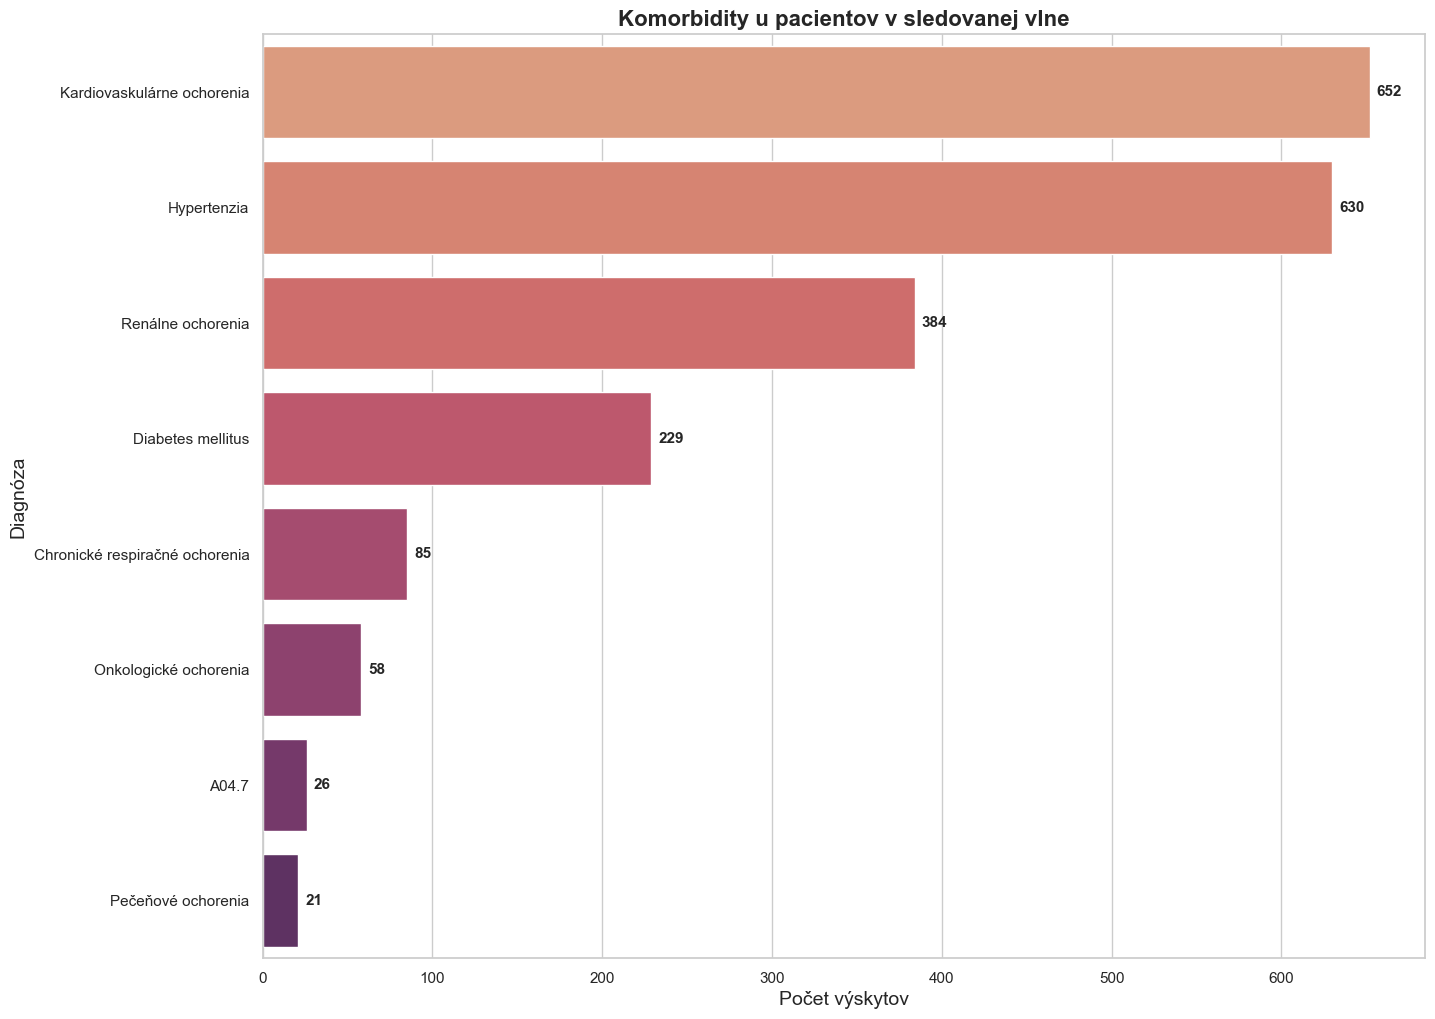

In [24]:
komorbidity_list = ['Renálne ochorenia', 'Hypertenzia', 'Kardiovaskulárne ochorenia', 'A04.7', "Onkologické ochorenia", "Chronické respiračné ochorenia", "Diabetes mellitus", "Pečeňové ochorenia"]

counts = vlna_1[komorbidity_list].sum().sort_values(ascending=False)
plt.figure(figsize=(15, 12))
ax = sns.barplot(x=counts.values, y=counts.index, palette='flare')

# pridanie čísel na koniec stĺpcov
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}', 
                (width, p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', 
                xytext=(5, 0), 
                textcoords='offset points',
                fontsize=11, fontweight='bold')
    
plt.title('Komorbidity u pacientov v sledovanej vlne', fontsize=16, fontweight='bold')
plt.xlabel('Počet výskytov', fontsize=14)
plt.ylabel('Diagnóza', fontsize=14)
plt.show()

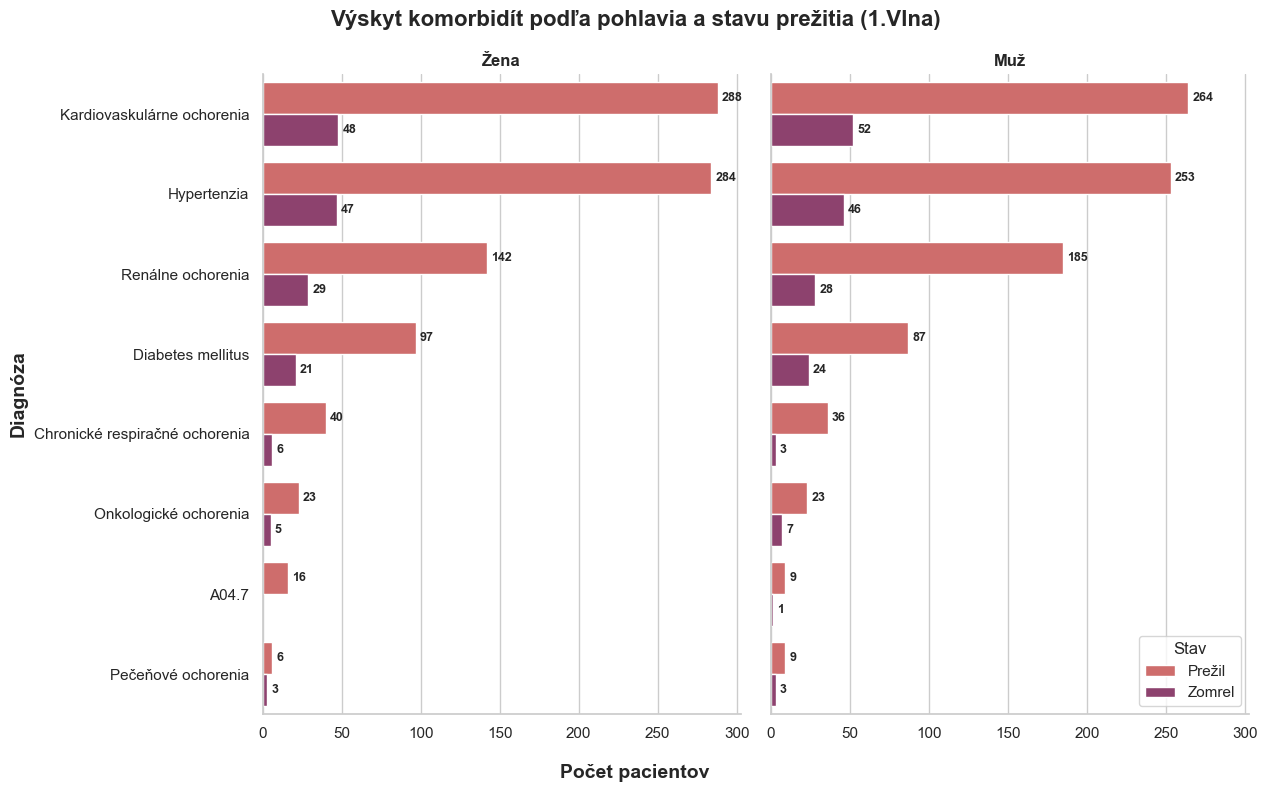

In [25]:
# 1. Príprava dát
df_subset = vlna_1[komorbidity_list + ['Zomrel', 'Pohlavie']]
df_melted = df_subset.melt(id_vars=['Zomrel', 'Pohlavie'], var_name='Komorbidita', value_name='Vyskyt')
df_plot = df_melted[df_melted['Vyskyt'] == 1].copy()

df_plot['Zomrel'] = df_plot['Zomrel'].replace({0: 'Prežil', 1: 'Zomrel'})

# 2. Vykreslenie
g = sns.catplot(
    data=df_plot, y='Komorbidita', hue='Zomrel', col='Pohlavie',
    kind='count', palette='flare', order=counts.index,
    height=8, aspect=0.8, legend=False 
)

# Pridanie čísel
for ax in g.axes.flat:
    for p in ax.patches:
        width = p.get_width()
        if width > 0:
            ax.annotate(f'{int(width)}', 
                        (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', xytext=(3, 0), 
                        textcoords='offset points', fontsize=9, fontweight='bold')

# Odstránime predvolené popisy (necháme prázdny reťazec pre X)
g.set_axis_labels("", "Diagnóza", ha='center', fontsize=14, fontweight='bold')
g.set_titles("{col_name}", fontweight='bold') 

# Pridanie legendy manuálne
#g.add_legend(title="Stav")

# PRIDANIE SPOLOČNÉHO POPISU OSI X DO STREDU
# x=0.5 je stred, y určuje výšku (0.02 je tesne nad spodným okrajom)
g.fig.text(0.5, 0.02, 'Počet pacientov', ha='center', fontsize=14, fontweight='bold')

plt.subplots_adjust(top=0.9, bottom=0.1) # Upravíme spodok, aby sa tam popis zmestil
g.fig.suptitle('Výskyt komorbidít podľa pohlavia a stavu prežitia (1.Vlna)', fontsize=16, fontweight='bold')
plt.legend(title='Stav', labels=['Prežil', 'Zomrel']) 
plt.show()


PROFIL PACIENTA S NAJDLHŠOU HOSPITALIZÁCIOU


In [26]:
najdlhsi_pacienti = vlna_1[vlna_1['Dĺžka hospitalizácie'] == max_dni]
print(najdlhsi_pacienti[['Pohlavie', 'Vek', 'Diagnózy', 'Liečba']])

    Pohlavie  Vek                                           Diagnózy  \
558     Žena   84  U07.1 | Potvrdená infekcia COVID-19 | Z; _x000...   

                                                Liečba  
558  00489 | KANAVIT | 1; _x000D_\n00498 | MAGNESIU...  


In [27]:
import pandas as pd
import re

# identifikácia pacienta s najdlhšou hospitalizáciou
max_dni = vlna_1['Dĺžka hospitalizácie'].max()
najdlhsi_pacienti = vlna_1[vlna_1['Dĺžka hospitalizácie'] == max_dni]

def vycisti_text_vsetko(text):
    if pd.isna(text):
        return []
    # odstránenie technického znaku _x000D_
    text = text.replace('_x000D_', '')
    polozky = text.split(';')
    vycistene = []
    for p in polozky:
        # odstránenie kódov na začiatku 
        p = re.sub(r'^[A-Z0-9.\s]+\|', '', p.strip())
        # odstránenie znakov na konci 
        p = re.sub(r'\|.*$', '', p).strip()
        if p and len(p) > 2:
            vycistene.append(p)
    return vycistene

print(f"=== KOMPLETNÝ KLINICKÝ PROFIL PACIENTA (NAJDLHŠIA HOSPITALIZÁCIA)===\n")

for i, row in najdlhsi_pacienti.iterrows():
    print(f"PACIENT ID: {i}")
    print(f"Stav: {row['Stav']}") # stav pacienta
    print(f"Demografia: {row['Pohlavie']}, {row['Vek']} rokov, Hospitalizácia: {max_dni} dní")
    print("-" * 60)
    
    # DIAGNÓZY
    diagnozy = vycisti_text_vsetko(row['Diagnózy'])
    print("STANOVENÉ DIAGNÓZY:")
    for d in diagnozy:
        print(f"  • {d}")
    print(f"\n--- Celkovo stanovených diagnóz: {len(diagnozy)} ---")
    
    print("-" * 60)
    
    # LIEČBA
    lieky = vycisti_text_vsetko(row['Liečba'])
    print("PODANÁ LIEČBA (Kompletný zoznam):")
    for l in lieky:
        print(f"  • {l}")
    print(f"\n--- Celkovo podaných položiek liečby: {len(lieky)} ---")
    
    print("="*60 + "\n")

=== KOMPLETNÝ KLINICKÝ PROFIL PACIENTA (NAJDLHŠIA HOSPITALIZÁCIA)===

PACIENT ID: 558
Stav: Zomrel
Demografia: Žena, 84 rokov, Hospitalizácia: 40 dní
------------------------------------------------------------
STANOVENÉ DIAGNÓZY:
  • Potvrdená infekcia COVID-19
  • Iný vírusový zápal pľúc
  • Fibrilácia a flater predsiení, bližšie neurčené
  • Primárna artériová hypertenzia, bližšie neurčená,
  • Chronická choroba obličiek, bližšie neurčená
  • Chronická ischemická choroba srdca, bližšie neurče
  • Hydronefróza pri obštrukcii kameňom obličky a močo
  • Koronavírus ako príčina chorôb zatriedených inde
  • Hypokaliémia

--- Celkovo stanovených diagnóz: 9 ---
------------------------------------------------------------
PODANÁ LIEČBA (Kompletný zoznam):
  • KANAVIT
  • MAGNESIUM SULFURICUM BBP 100 MG/ML INJEKČNÝ ROZTOK
  • MORPHIN BIOTIKA 1%
  • DITHIADEN
  • KALIUM CHLORATUM LÉČIVA 7,5 %
  • PREDNISON 20 LÉČIVA
  • DITHIADEN INJ
  • ATORIS 30
  • OZZION 20 MG GASTROREZISTENTNÉ TABLETY
  

GRAF POMERU PREŽITIA A ÚMRTIA PODĽA POHLAVIA

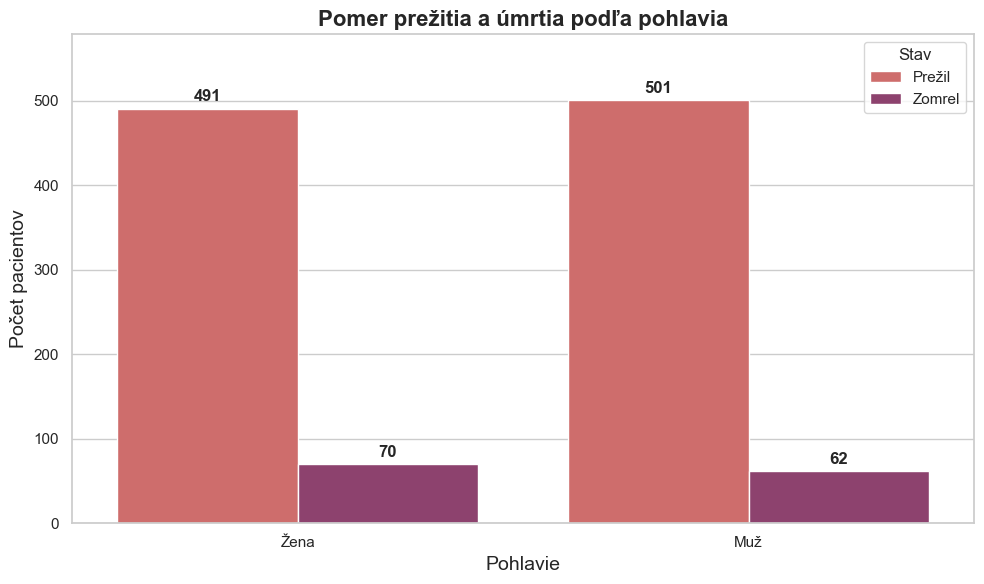

In [28]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.countplot(data=vlna_1, x="Pohlavie", hue="Zomrel", ax=ax, palette='flare')

for container in ax.containers:
    ax.bar_label(container, fontsize=12, padding=3, fontweight='bold')

ax.set_xlabel("Pohlavie", fontsize=14)
ax.set_ylabel("Počet pacientov", fontsize=14)
ax.set_title("Pomer prežitia a úmrtia podľa pohlavia", fontsize=16, fontweight='bold')

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Prežil', 'Zomrel'], title="Stav", loc='upper right')

ax.set_ylim(0, ax.get_ylim()[1] * 1.1)

plt.tight_layout()
plt.show()

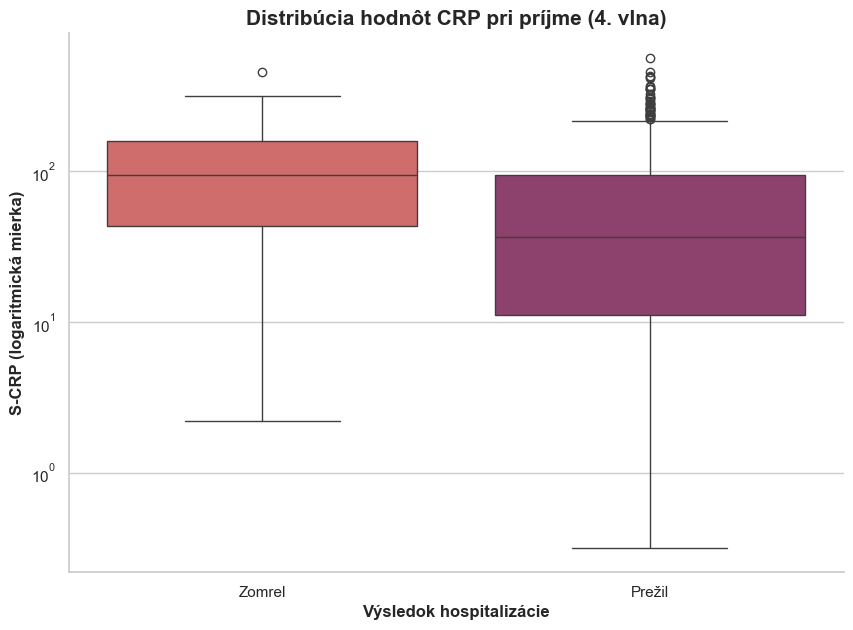

In [29]:
# 1. POISTKA: Skontrolujeme, či 'Zomrel' existuje.
if 'Zomrel' not in vlna_4.columns:
    if 'Závažnosť priebehu ochorenia' in vlna_4.columns:
        vlna_4['Zomrel'] = (vlna_4['Závažnosť priebehu ochorenia'] == 3)
    else:
        print("Chyba: Stĺpec 'Zomrel' sa nenašiel. Dostupné stĺpce sú:", vlna_4.columns.tolist())

# 2. Príprava stĺpca 'Stav' a kontrola typov
# Uistíme sa, že 'Zomrel' je typu bool alebo int (0/1) pre mapovanie
vlna_4['Zomrel'] = vlna_4['Zomrel'].astype(int)
vlna_4['Stav'] = vlna_4['Zomrel'].map({1: 'Zomrel', 0: 'Prežil'})


plt.figure(figsize=(10, 7))

# Vytvorenie stĺpca Stav pre obe vlny
for df in [vlna_1, vlna_4]:
    df['Stav'] = df['Zomrel'].map({1: 'Zomrel', 0: 'Prežil', True: 'Zomrel', False: 'Prežil'})

# Boxplot pre 4. vlnu
sns.boxplot(data=vlna_4, x='Stav', y='S-CRP first', palette='flare', hue='Stav', legend=False)

plt.yscale('log') # CRP máva obrovské rozpätie (od 1 do 500)
plt.title('Distribúcia hodnôt CRP pri príjme (4. vlna)', fontsize=15, fontweight='bold')
plt.ylabel('S-CRP (logaritmická mierka)', fontsize=12, fontweight='bold')
plt.xlabel('Výsledok hospitalizácie', fontsize=12, fontweight='bold')
sns.despine()
plt.show()

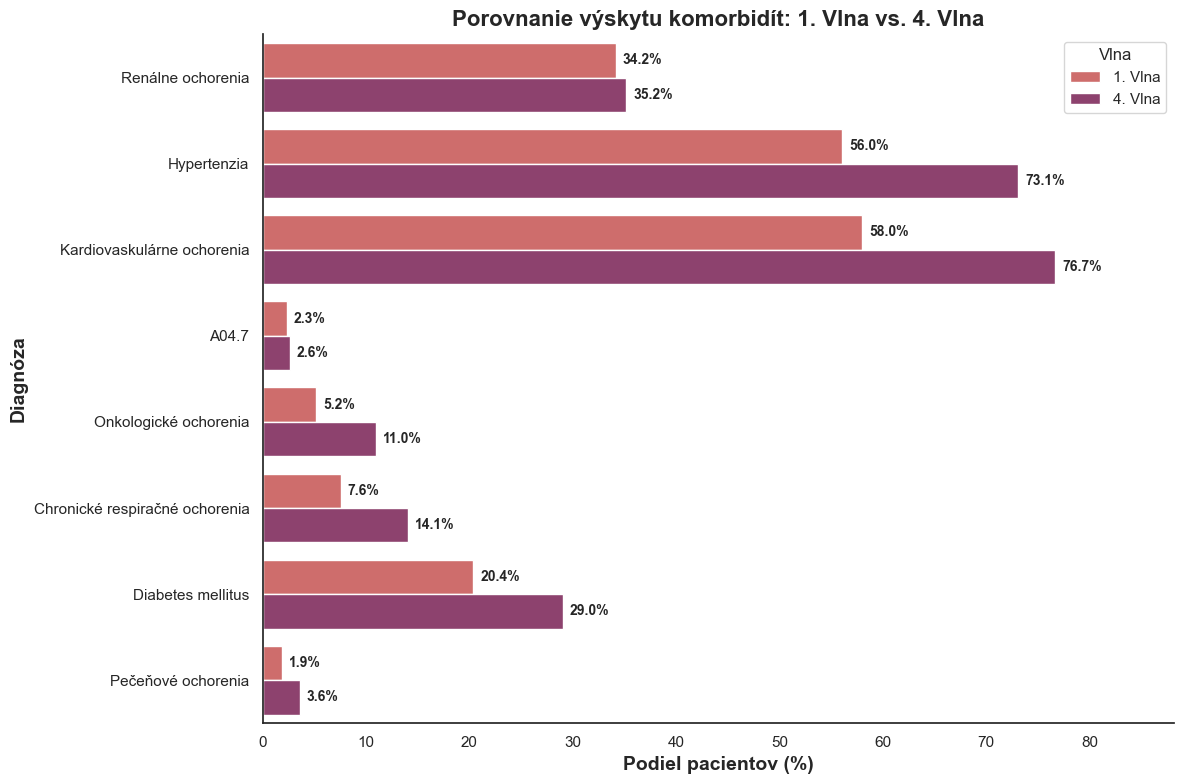

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Príprava dát (vaša pôvodná logika)
komorbidity = ['Renálne ochorenia', 'Hypertenzia', 'Kardiovaskulárne ochorenia', 'A04.7', 
               "Onkologické ochorenia", "Chronické respiračné ochorenia", 
               "Diabetes mellitus", "Pečeňové ochorenia"]

v1_sums = (vlna_1[komorbidity].sum() / len(vlna_1)) * 100
v4_sums = (vlna_4[komorbidity].sum() / len(vlna_4)) * 100

df_comp = pd.DataFrame({'1. Vlna': v1_sums, '4. Vlna': v4_sums}).reset_index()
df_comp = df_comp.melt(id_vars='index', var_name='Vlna', value_name='Percento')

# 2. Vykreslenie
sns.set_style("white")
plt.figure(figsize=(12, 8))

# Vytvorenie grafu
ax = sns.barplot(data=df_comp, x='Percento', y='index', hue='Vlna', palette='flare')

# PRIDANIE ČÍSELNÝCH HODNÔT NA KONIEC STĹPCOV
for p in ax.patches:
    width = p.get_width()
    if width > 0: # Zobrazíme len nenulové hodnoty
        ax.annotate(f'{width:.1f}%', 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(5, 0), # Posun textu o 5 bodov doprava od konca stĺpca
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

# Formátovanie
plt.title('Porovnanie výskytu komorbidít: 1. Vlna vs. 4. Vlna', fontsize=16, fontweight='bold')
plt.xlabel('Podiel pacientov (%)', fontsize=14, fontweight='bold')
plt.ylabel('Diagnóza', fontsize=14, fontweight='bold')

# Rozšírenie osi X, aby sa tam zmestili popisky
plt.xlim(0, df_comp['Percento'].max() * 1.15) 

sns.despine()
plt.tight_layout()
plt.show()

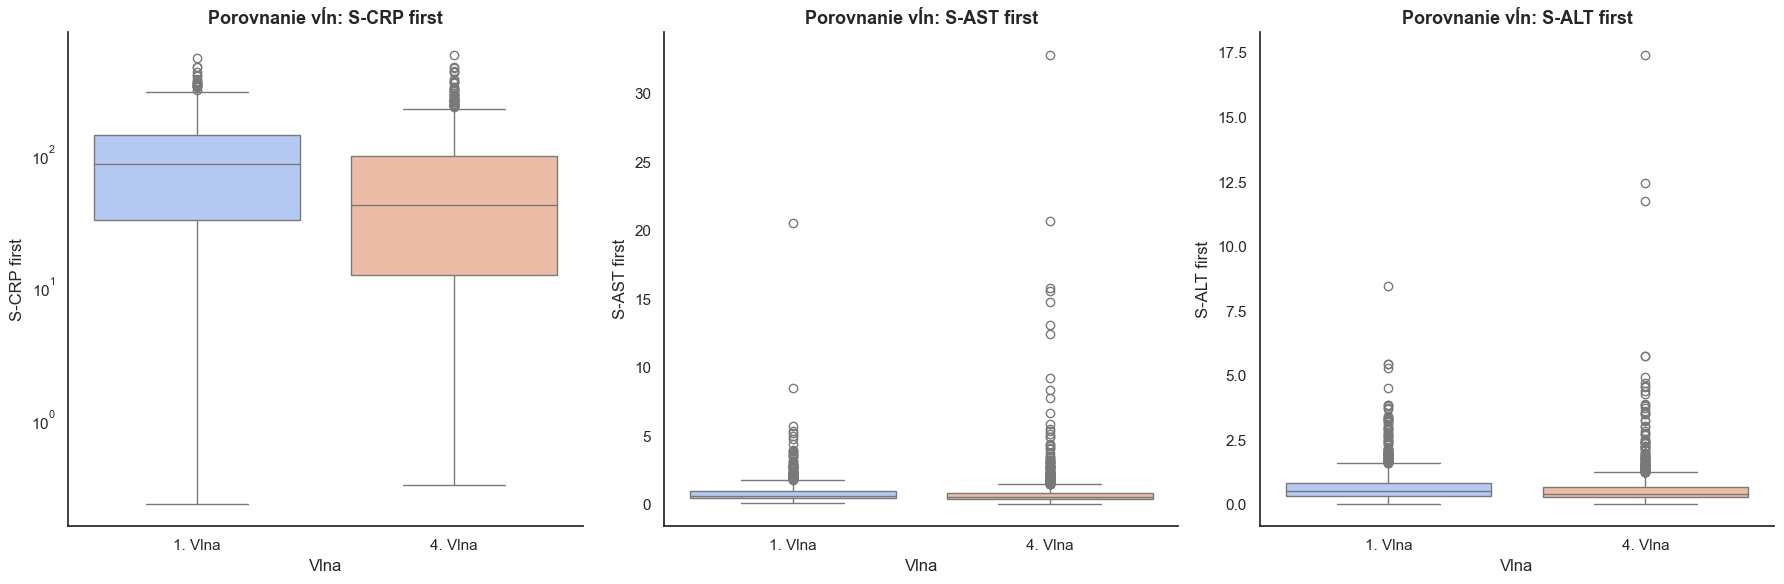

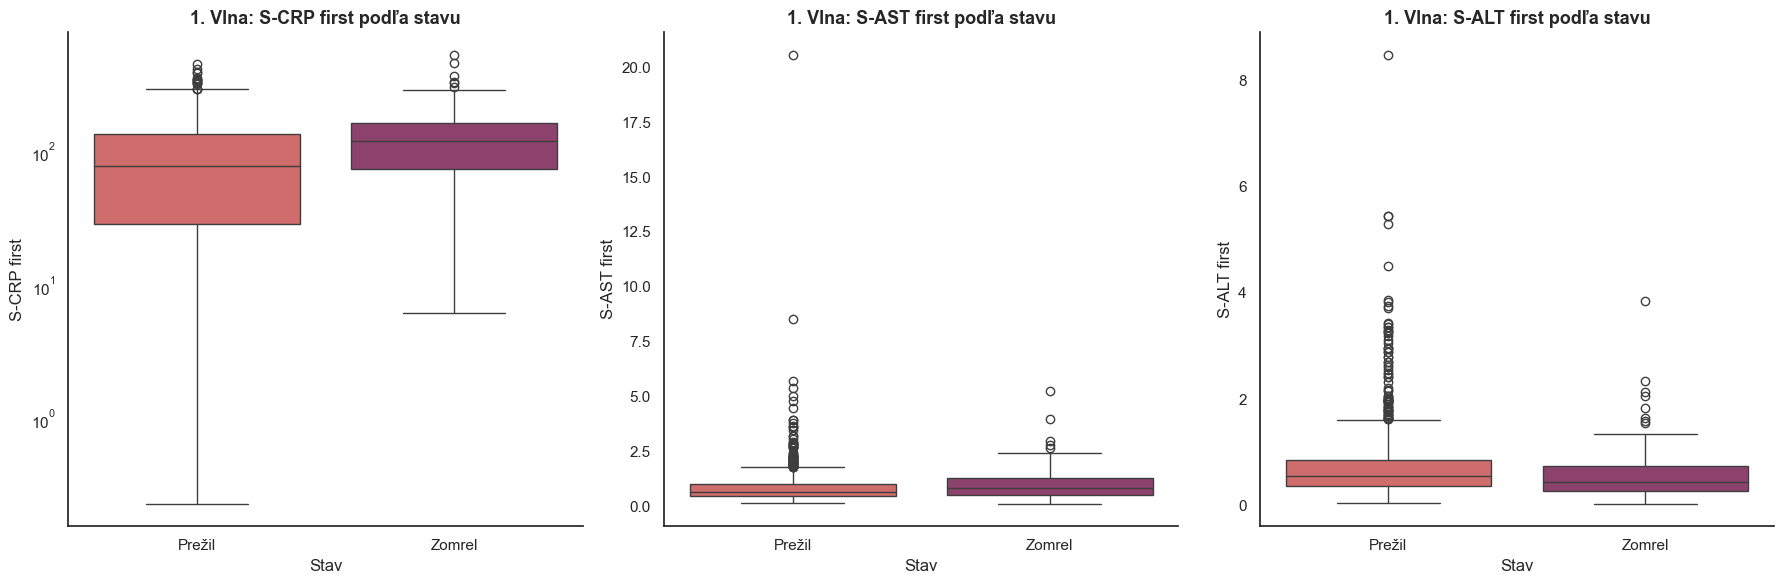

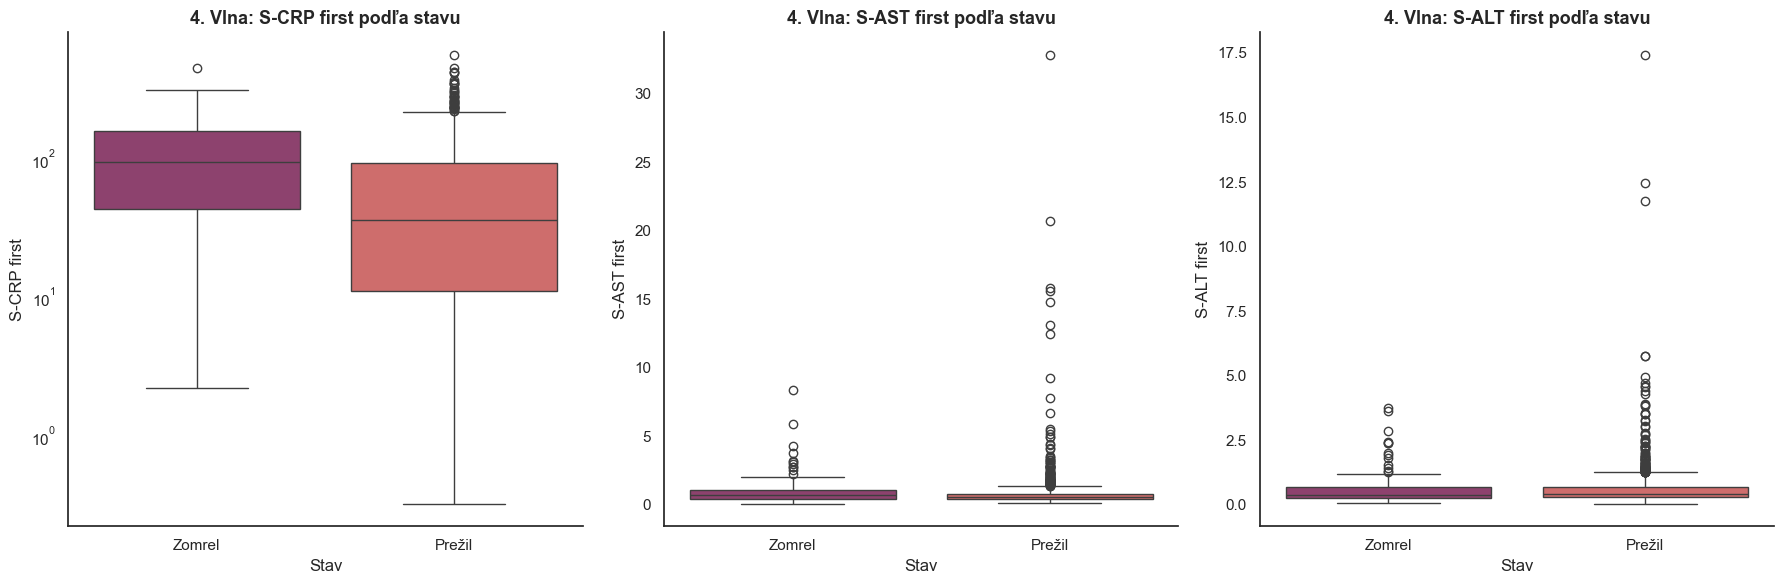

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Nastavenie štýlu
sns.set_style("white")
attrs = ['S-CRP first', 'S-AST first', 'S-ALT first']

# 1. PRÍPRAVA DÁT
vlna_1['Vlna'] = '1. Vlna'
vlna_4['Vlna'] = '4. Vlna'

# Funkcia na zjednotenie stavu pacienta
for df in [vlna_1, vlna_4]:
    if 'Zomrel' not in df.columns:
        if 'Závažnosť priebehu ochorenia' in df.columns:
            df['Stav'] = df['Závažnosť priebehu ochorenia'].map({3: 'Zomrel', 1: 'Prežil', 2: 'Prežil'})
        else:
            df['Stav'] = 'Neznáme'
    else:
        df['Stav'] = df['Zomrel'].map({1: 'Zomrel', 0: 'Prežil', True: 'Zomrel', False: 'Prežil', 1.0: 'Zomrel', 0.0: 'Prežil'})

# --- GRAF 1: POROVNANIE MEDZI VLNAMI ---
df_combined = pd.concat([vlna_1[attrs + ['Vlna']], vlna_4[attrs + ['Vlna']]], ignore_index=True)
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')

for i, attr in enumerate(attrs):
    sns.boxplot(data=df_combined, x='Vlna', y=attr, ax=axes1[i], palette='coolwarm', hue='Vlna')
    axes1[i].set_title(f'Porovnanie vĺn: {attr}', fontsize=13, fontweight='bold')
    if 'CRP' in attr: axes1[i].set_yscale('log')
    sns.despine(ax=axes1[i])

plt.tight_layout()
plt.show()

# --- GRAF 2: DETAILNÝ POHĽAD NA 1. VLNU (STAV PACIENTA) ---
# Odstránime 'Neznáme', ak by sa v dátach vyskytli, aby bol graf čistý
v1_plot = vlna_1[vlna_1['Stav'].isin(['Prežil', 'Zomrel'])]

fig2, axes2 = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
for i, attr in enumerate(attrs):
    sns.boxplot(data=v1_plot, x='Stav', y=attr, ax=axes2[i], palette='flare', 
                hue='Stav', hue_order=['Prežil', 'Zomrel'])
    axes2[i].set_title(f'1. Vlna: {attr} podľa stavu', fontsize=13, fontweight='bold')
    if 'CRP' in attr: axes2[i].set_yscale('log')
    sns.despine(ax=axes2[i])

plt.tight_layout()
plt.show()

# --- GRAF 3: DETAILNÝ POHĽAD NA 4. VLNU (STAV PACIENTA) ---
v4_plot = vlna_4[vlna_4['Stav'].isin(['Prežil', 'Zomrel'])]

fig3, axes3 = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')
for i, attr in enumerate(attrs):
    sns.boxplot(data=v4_plot, x='Stav', y=attr, ax=axes3[i], palette='flare', 
                hue='Stav', hue_order=['Prežil', 'Zomrel'])
    axes3[i].set_title(f'4. Vlna: {attr} podľa stavu', fontsize=13, fontweight='bold')
    if 'CRP' in attr: axes3[i].set_yscale('log')
    sns.despine(ax=axes3[i])

plt.tight_layout()
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


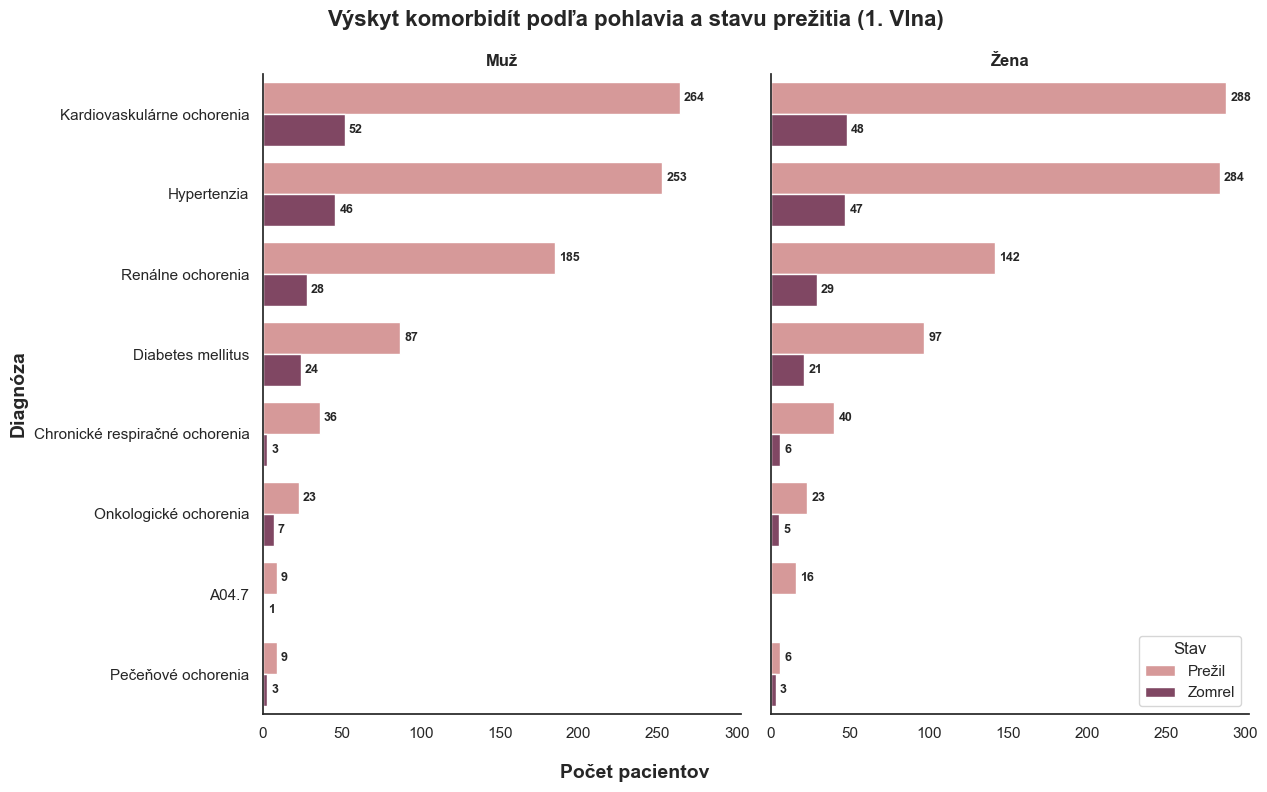

In [34]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ===================================================================
# NASTAVENIE PRE KONKRÉTNU VLNU
# ===================================================================
# TU ZMEŇ DATASET PODĽA TOHO, V KTOROM NOTEBOOKU SA NACHÁDZAŠ
aktualna_vlna = vlna_1  # <--- Zmeň na vlna_4 pre štvrtú vlnu
nazov_grafu = 'Výskyt komorbidít podľa pohlavia a stavu prežitia (1. Vlna)'

# Zoznam stĺpcov diagnóz, ktoré chceš vizualizovať
komorbidity_list = ['Kardiovaskulárne ochorenia', 'Hypertenzia', 'Renálne ochorenia', 
                    'Diabetes mellitus', 'Chronické respiračné ochorenia', 
                    'Onkologické ochorenia', 'A04.7', 'Pečeňové ochorenia']

# ===================================================================
# 1. PRÍPRAVA DÁT
# ===================================================================
df_subset = aktualna_vlna[komorbidity_list + ['Zomrel', 'Pohlavie']].copy()

# BEZPEČNÁ TRANSFORMÁCIA: Prevedieme 0 a 1 na text rovno na začiatku. 
# Zabezpečíme tak, že sa v legende nič nevymení.
df_subset['Zomrel'] = df_subset['Zomrel'].map({0: 'Prežil', 1: 'Zomrel'})

# "Roztavenie" dátovej matice do formátu vhodného pre catplot
df_melted = df_subset.melt(id_vars=['Zomrel', 'Pohlavie'], var_name='Komorbidita', value_name='Vyskyt')

# Vyfiltrujeme len tie riadky, kde pacient danú chorobu skutočne má (hodnota True alebo 1)
df_plot = df_melted[df_melted['Vyskyt'] == True].copy()

# Zistíme celkový počet výskytov, aby sme graf zotriedili od najčastejšej choroby nadol
counts = df_plot['Komorbidita'].value_counts()

# ===================================================================
# 2. VYKRESLENIE GRAFU
# ===================================================================
g = sns.catplot(
    data=df_plot, y='Komorbidita', hue='Zomrel', col='Pohlavie',
    kind='count', 
    hue_order=['Prežil', 'Zomrel'], # EXPLICITNÉ PORADIE
    palette={'Prežil': '#e08f8f', 'Zomrel': '#8a3d63'}, # FIXNÉ FARBY (už sa nikdy nepomýlia)
    order=counts.index,
    height=8, aspect=0.8, legend=False 
)

# Pridanie textových hodnôt priamo za stĺpce
for ax in g.axes.flat:
    for p in ax.patches:
        width = p.get_width()
        # Ošetrenie proti prázdnym hodnotám (NaN)
        if not np.isnan(width) and width > 0:
            ax.annotate(f'{int(width)}', 
                        (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', xytext=(3, 0), 
                        textcoords='offset points', fontsize=9, fontweight='bold')

# Odstránenie prebytočných textov osí (čistý dizajn)
g.set_axis_labels("", "Diagnóza", ha='center', fontsize=14, fontweight='bold')
g.set_titles("{col_name}", fontweight='bold') 

# Pridanie spoločného popisu pre os X
g.fig.text(0.5, 0.02, 'Počet pacientov', ha='center', fontsize=14, fontweight='bold')

# Nadpis a posunutie okrajov (aby nadpis neprekrýval grafy)
g.fig.suptitle(nazov_grafu, fontsize=16, fontweight='bold')
plt.subplots_adjust(top=0.90, bottom=0.1) 

# Definitívne zobrazenie spoľahlivej legendy
plt.legend(title='Stav pacienta', loc='lower right')
plt.legend(title='Stav', labels=['Prežil', 'Zomrel']) 
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


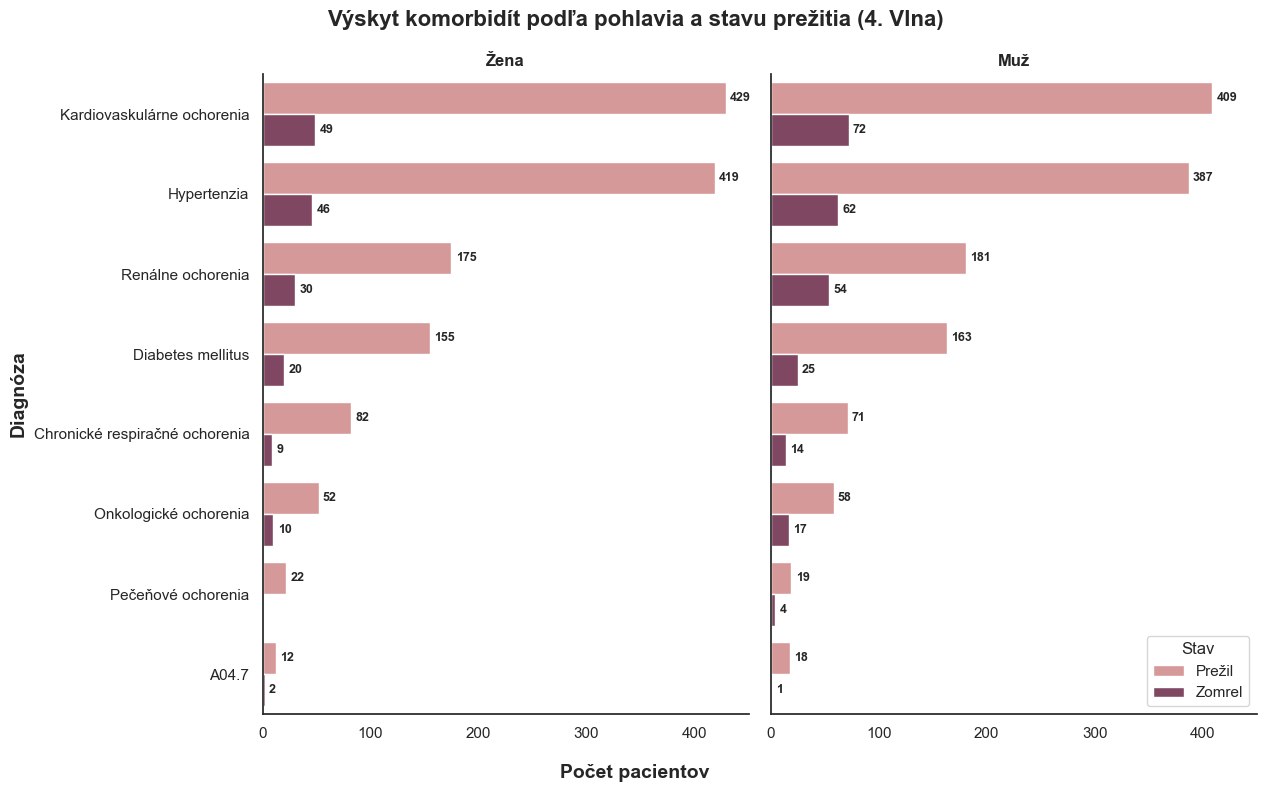

In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ===================================================================
# NASTAVENIE PRE KONKRÉTNU VLNU
# ===================================================================
# TU ZMEŇ DATASET PODĽA TOHO, V KTOROM NOTEBOOKU SA NACHÁDZAŠ
aktualna_vlna = vlna_4  # <--- Zmeň na vlna_4 pre štvrtú vlnu
nazov_grafu = 'Výskyt komorbidít podľa pohlavia a stavu prežitia (4. Vlna)'

# Zoznam stĺpcov diagnóz, ktoré chceš vizualizovať
komorbidity_list = ['Kardiovaskulárne ochorenia', 'Hypertenzia', 'Renálne ochorenia', 
                    'Diabetes mellitus', 'Chronické respiračné ochorenia', 
                    'Onkologické ochorenia', 'A04.7', 'Pečeňové ochorenia']

# ===================================================================
# 1. PRÍPRAVA DÁT
# ===================================================================
df_subset = aktualna_vlna[komorbidity_list + ['Zomrel', 'Pohlavie']].copy()

# BEZPEČNÁ TRANSFORMÁCIA: Prevedieme 0 a 1 na text rovno na začiatku. 
# Zabezpečíme tak, že sa v legende nič nevymení.
df_subset['Zomrel'] = df_subset['Zomrel'].map({0: 'Prežil', 1: 'Zomrel'})

# "Roztavenie" dátovej matice do formátu vhodného pre catplot
df_melted = df_subset.melt(id_vars=['Zomrel', 'Pohlavie'], var_name='Komorbidita', value_name='Vyskyt')

# Vyfiltrujeme len tie riadky, kde pacient danú chorobu skutočne má (hodnota True alebo 1)
df_plot = df_melted[df_melted['Vyskyt'] == True].copy()

# Zistíme celkový počet výskytov, aby sme graf zotriedili od najčastejšej choroby nadol
counts = df_plot['Komorbidita'].value_counts()

# ===================================================================
# 2. VYKRESLENIE GRAFU
# ===================================================================
g = sns.catplot(
    data=df_plot, y='Komorbidita', hue='Zomrel', col='Pohlavie',
    kind='count', 
    hue_order=['Prežil', 'Zomrel'], # EXPLICITNÉ PORADIE
    palette={'Prežil': '#e08f8f', 'Zomrel': '#8a3d63'}, # FIXNÉ FARBY (už sa nikdy nepomýlia)
    order=counts.index,
    height=8, aspect=0.8, legend=False 
)

# Pridanie textových hodnôt priamo za stĺpce
for ax in g.axes.flat:
    for p in ax.patches:
        width = p.get_width()
        # Ošetrenie proti prázdnym hodnotám (NaN)
        if not np.isnan(width) and width > 0:
            ax.annotate(f'{int(width)}', 
                        (width, p.get_y() + p.get_height() / 2.),
                        ha='left', va='center', xytext=(3, 0), 
                        textcoords='offset points', fontsize=9, fontweight='bold')

# Odstránenie prebytočných textov osí (čistý dizajn)
g.set_axis_labels("", "Diagnóza", ha='center', fontsize=14, fontweight='bold')
g.set_titles("{col_name}", fontweight='bold') 

# Pridanie spoločného popisu pre os X
g.fig.text(0.5, 0.02, 'Počet pacientov', ha='center', fontsize=14, fontweight='bold')

# Nadpis a posunutie okrajov (aby nadpis neprekrýval grafy)
g.fig.suptitle(nazov_grafu, fontsize=16, fontweight='bold')
plt.subplots_adjust(top=0.90, bottom=0.1) 

# Definitívne zobrazenie spoľahlivej legendy
plt.legend(title='Stav pacienta', loc='lower right')
plt.legend(title='Stav', labels=['Prežil', 'Zomrel']) 
plt.show()